# IOHMM Volatility Visualization

读取 IOHMM 输出并按 `HMM/rv_prediction.ipynb`、`HMM/return_prediction.ipynb` 的风格进行可视化。

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'IOHMM_add':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != 'cu_saf':
    for p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if p.name == 'cu_saf':
            PROJECT_ROOT = p
            break

PIC_DIR = PROJECT_ROOT / 'IOHMM_add' / 'pic'
PIC_DIR.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('PIC_DIR =', PIC_DIR)

PROJECT_ROOT = E:\CodeSpace\2026_mafn\cu_saf
PIC_DIR = E:\CodeSpace\2026_mafn\cu_saf\IOHMM_add\pic


In [35]:
# 1) 自动定位 IOHMM output 文件
# 预测曲线必须来自“真实预测输出”；train_results 只用于状态分析。
pred_candidate_paths = [
    PROJECT_ROOT / 'IOHMM_add' / 'outputs' / 'iohmm_predictions.csv',
    PROJECT_ROOT / 'IOHMM' / 'experiments' / 'spy_vol_iohmm_results.csv',
]
state_candidate_path = PROJECT_ROOT / 'IOHMM' / 'experiments' / 'spy_vol_iohmm_train_results.csv'

pred_existing = [p for p in pred_candidate_paths if p.exists()]
if not pred_existing:
    raise FileNotFoundError(
        '未找到可用预测文件（iohmm_predictions.csv / spy_vol_iohmm_results.csv / iohmm_canonical_predictions.csv）。'
    )

pred_path = pred_existing[0]
print('Using prediction file:', pred_path)

df = pd.read_csv(pred_path)
print('pred columns:', df.columns.tolist())

state_df = None
if state_candidate_path.exists():
    state_df = pd.read_csv(state_candidate_path)
    print('Using state file:', state_candidate_path)
    print('state columns:', state_df.columns.tolist())
else:
    print('State file not found:', state_candidate_path)

df.head()

FileNotFoundError: 未找到可用预测文件（iohmm_predictions.csv / spy_vol_iohmm_results.csv / iohmm_canonical_predictions.csv）。

In [ ]:
# 2) 统一字段：构造 date / true_vol / pred_vol / state
# 关键修正：pred 只能来自模型输出的预测列，不能用 train_results 的 state 概率反推。
if 'date' in df.columns:
    date_col = 'date'
elif 'Date' in df.columns:
    date_col = 'Date'
else:
    raise ValueError('预测文件缺少 date/Date 列。')

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

if {'y_true_rv', 'y_pred_rv'}.issubset(df.columns):
    true_rv = pd.to_numeric(df['y_true_rv'], errors='coerce')
    pred_rv = pd.to_numeric(df['y_pred_rv'], errors='coerce')
    pred_source = 'direct y_pred_rv'
elif {'y_true_log', 'y_pred_log'}.issubset(df.columns):
    true_rv = np.exp(pd.to_numeric(df['y_true_log'], errors='coerce'))
    pred_rv = np.exp(pd.to_numeric(df['y_pred_log'], errors='coerce'))
    pred_source = 'direct y_pred_log'
elif {'y_true_rv_gk', 'y_iohmm_pred'}.issubset(df.columns):
    true_rv = pd.to_numeric(df['y_true_rv_gk'], errors='coerce')
    pred_rv = pd.to_numeric(df['y_iohmm_pred'], errors='coerce')
    pred_source = 'direct y_iohmm_pred'
else:
    raise ValueError('当前预测文件不含可用预测列；请使用 iohmm_predictions / spy_vol_iohmm_results / iohmm_canonical_predictions。')

viz = pd.DataFrame({'date': df[date_col], 'true_rv': true_rv, 'pred_rv': pred_rv})

# 状态信息优先从 state_df（train_results）按日期合并；否则尝试预测文件自带状态列
if state_df is not None:
    sd = state_df.copy()
    state_date_col = 'date' if 'date' in sd.columns else ('Date' if 'Date' in sd.columns else None)
    if state_date_col is not None and 'state' in sd.columns:
        sd[state_date_col] = pd.to_datetime(sd[state_date_col])
        sd = sd[[state_date_col, 'state']].rename(columns={state_date_col: 'date'})
        sd['state'] = pd.to_numeric(sd['state'], errors='coerce').astype('Int64')
        viz = viz.merge(sd, on='date', how='left')
    else:
        viz['state'] = pd.Series([pd.NA] * len(viz), dtype='Int64')
elif 'dom_state' in df.columns:
    viz['state'] = pd.to_numeric(df['dom_state'], errors='coerce').astype('Int64')
elif 'state' in df.columns:
    viz['state'] = pd.to_numeric(df['state'], errors='coerce').astype('Int64')
else:
    viz['state'] = pd.Series([pd.NA] * len(viz), dtype='Int64')

# 概率列也优先取 train_results，便于状态概率图
if state_df is not None:
    prob_df = state_df.copy()
    prob_date_col = 'date' if 'date' in prob_df.columns else ('Date' if 'Date' in prob_df.columns else None)
    if prob_date_col is not None:
        prob_df[prob_date_col] = pd.to_datetime(prob_df[prob_date_col])
        prob_df = prob_df.rename(columns={prob_date_col: 'date'})
        p_cols = sorted([c for c in prob_df.columns if c.startswith('p_state_') or c.startswith('p_')])
        if p_cols:
            viz = viz.merge(prob_df[['date', *p_cols]], on='date', how='left')
        else:
            p_cols = []
    else:
        p_cols = []
else:
    p_cols = sorted([c for c in df.columns if c.startswith('p_state_') or c.startswith('p_')])
    if p_cols:
        viz = viz.merge(df[[date_col, *p_cols]].rename(columns={date_col: 'date'}), on='date', how='left')

viz['pred_source'] = pred_source
viz['true_vol'] = np.sqrt(viz['true_rv']) * 100.0
viz['pred_vol'] = np.sqrt(viz['pred_rv']) * 100.0

viz = viz.dropna(subset=['true_vol', 'pred_vol']).reset_index(drop=True)
print('pred_source =', viz['pred_source'].iloc[0])
print('rows =', len(viz))
viz.head()

pred_source = direct prediction column


,date,true_rv,state,pred_rv,pred_source,true_vol,pred_vol
0,2020-01-31,0.024101,<NA>,0.012442,direct prediction column,15.524485,11.154518
1,2020-02-03,0.009780,<NA>,0.019294,direct prediction column,9.889444,13.890387
2,2020-02-04,0.005226,<NA>,0.012252,direct prediction column,7.228992,11.068848
3,2020-02-05,0.006393,<NA>,0.008175,direct prediction column,7.995643,9.041589
4,2020-02-06,0.002185,<NA>,0.003406,direct prediction column,4.674026,5.836450


In [ ]:
# 3) 基本指标（volatility-percentage scale）
err = viz['pred_vol'] - viz['true_vol']
rmse = float(np.sqrt(np.mean(err**2)))
mae = float(np.mean(np.abs(err)))

eps = 1e-12
ratio = np.maximum(viz['true_rv'], eps) / np.maximum(viz['pred_rv'], eps)
qlike_series = ratio - np.log(ratio) - 1.0
avg_qlike = float(np.mean(qlike_series))

print(f'n={len(viz)}')
print(f'RMSE(vol %): {rmse:.4f}')
print(f'MAE(vol %):  {mae:.4f}')
print(f'QLIKE:       {avg_qlike:.6f}')

n=1238
RMSE(vol %): 13.7377
MAE(vol %):  5.7979
QLIKE:       4.271358


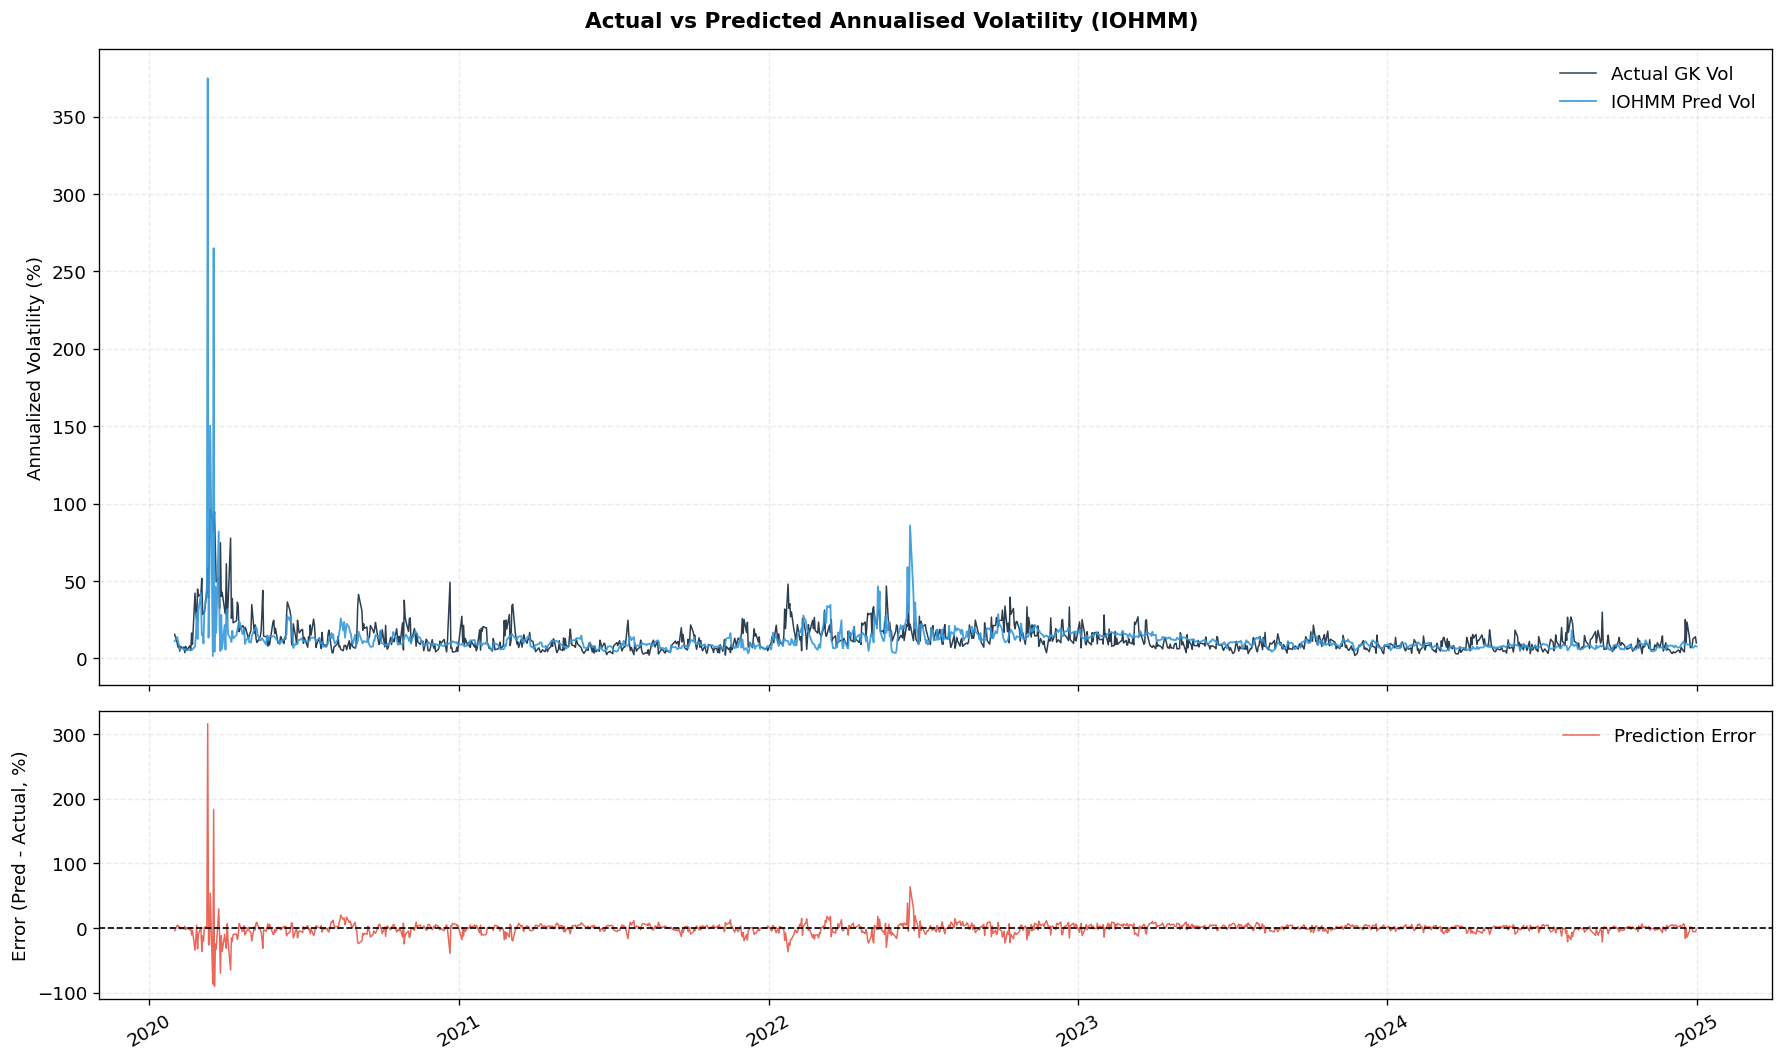

In [ ]:
# 4) 主图：Actual vs Predicted + Error（风格对齐 HMM notebook）
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})
fig.suptitle('Actual vs Predicted Annualised Volatility (IOHMM)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(viz['date'], viz['true_vol'], color='#2c3e50', lw=0.9, label='Actual GK Vol')

if 'pred_vol_soft' in viz.columns and 'pred_vol_hard' in viz.columns:
    ax.plot(viz['date'], viz['pred_vol_soft'], color='#3498db', lw=1.2, alpha=0.9, label='IOHMM soft pred (prob-weighted)')
    ax.plot(viz['date'], viz['pred_vol_hard'], color='#e67e22', lw=1.0, alpha=0.8, ls='--', label='IOHMM hard pred (argmax state)')
else:
    ax.plot(viz['date'], viz['pred_vol'], color='#3498db', lw=1.1, alpha=0.9, label='IOHMM Pred Vol')

ax.set_ylabel('Annualized Volatility (%)')
ax.grid(alpha=0.25, ls='--')
ax.legend(frameon=False, loc='upper right')

ax = axes[1]
if 'pred_vol_soft' in viz.columns and 'pred_vol_hard' in viz.columns:
    err_soft = viz['pred_vol_soft'] - viz['true_vol']
    err_hard = viz['pred_vol_hard'] - viz['true_vol']
    ax.plot(viz['date'], err_soft, color='#3498db', lw=0.9, alpha=0.85, label='Soft prediction error')
    ax.plot(viz['date'], err_hard, color='#e67e22', lw=0.8, alpha=0.75, ls='--', label='Hard prediction error')
else:
    ax.plot(viz['date'], err, color='#e74c3c', lw=0.9, alpha=0.85, label='Prediction Error')

ax.axhline(0, color='black', lw=1, ls='--')
ax.set_ylabel('Error (Pred - Actual, %)')
ax.grid(alpha=0.25, ls='--')
ax.legend(frameon=False, loc='upper right')

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PIC_DIR / 'iohmm_vol_fig01_forecast.png', dpi=200, bbox_inches='tight')
plt.show()

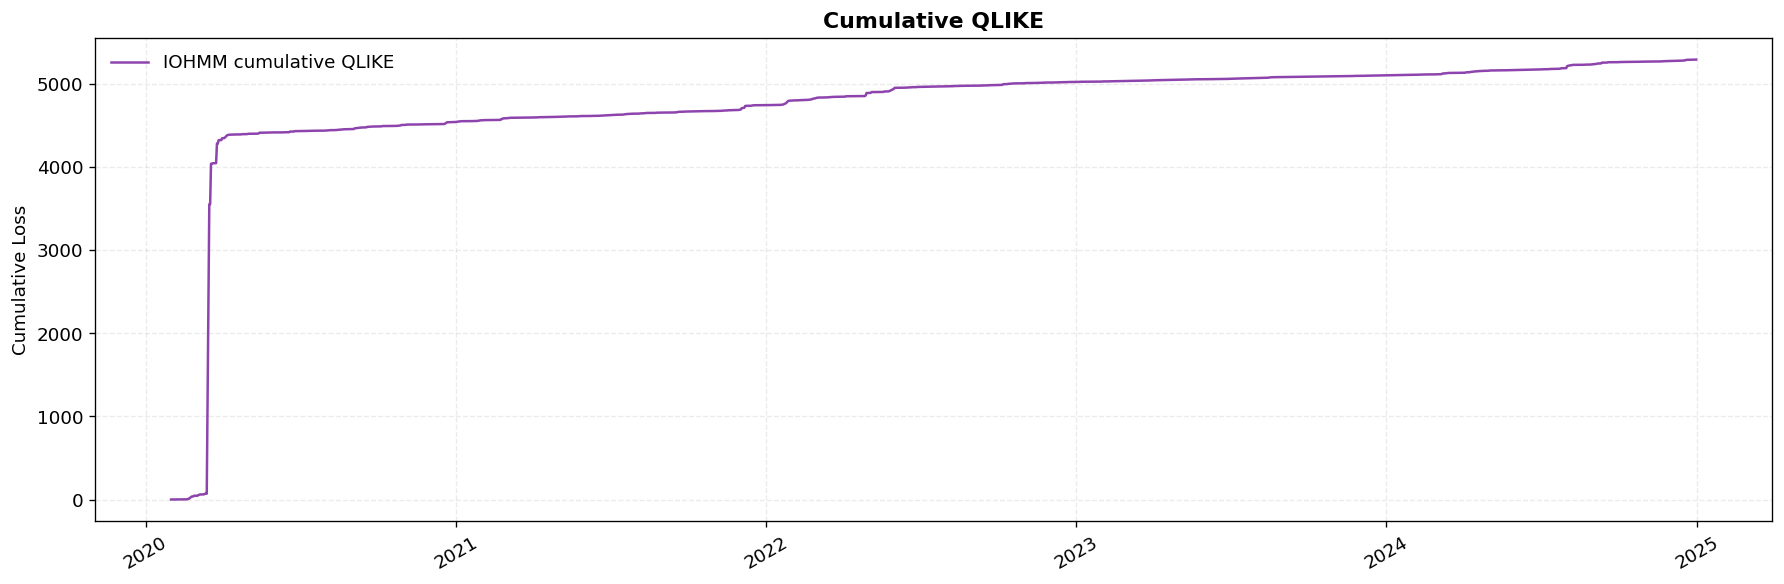

In [ ]:
# 5) 累计 QLIKE 曲线（类似 rv_prediction 的累计损失图）
cum_ql = qlike_series.cumsum()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(viz['date'], cum_ql, color='#8e44ad', lw=1.5, label='IOHMM cumulative QLIKE')
ax.set_title('Cumulative QLIKE', fontweight='bold')
ax.set_ylabel('Cumulative Loss')
ax.grid(alpha=0.25, ls='--')
ax.legend(frameon=False)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PIC_DIR / 'iohmm_vol_fig02_qlike.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# 6) 状态可视化（若存在 dom_state/state）
if viz['state'].notna().any():
    state_series = viz['state'].astype('Int64')
    states = sorted([int(s) for s in state_series.dropna().unique()])
    cmap = plt.get_cmap('Set2', max(len(states), 1))
    colors = {s: cmap(i) for i, s in enumerate(states)}

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})
    fig.suptitle('IOHMM Volatility with Dominant Regime', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot(viz['date'], viz['true_vol'], color='#2c3e50', lw=0.8, label='Actual Vol', zorder=2)
    ax.plot(viz['date'], viz['pred_vol'], color='#3498db', lw=1.0, alpha=0.8, label='IOHMM Pred Vol', zorder=2)

    state_np = state_series.to_numpy()
    dates_np = viz['date'].to_numpy()
    start = 0
    for i in range(1, len(state_np) + 1):
        change = i == len(state_np) or state_np[i] != state_np[start]
        if change:
            s = state_np[start]
            if pd.notna(s):
                ax.axvspan(dates_np[start], dates_np[i - 1], color=colors[int(s)], alpha=0.40, lw=0)
            start = i

    ax.set_ylabel('Annualized Volatility (%)')
    ax.grid(alpha=0.22, ls='--')
    ax.legend(frameon=False, loc='upper right')

    ax2 = axes[1]
    ax2.step(viz['date'], state_series.fillna(-1), where='post', color='#e67e22', lw=1.1)
    ax2.set_ylabel('Dominant State')
    ax2.set_xlabel('Date')
    ax2.grid(alpha=0.22, ls='--')

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PIC_DIR / 'iohmm_vol_fig03_states.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('当前输出不包含 state/dom_state，跳过状态可视化。')

当前输出不包含 state/dom_state，跳过状态可视化。


In [ ]:
# 8) 保存整理后的可视化输入数据
out_path = PROJECT_ROOT / 'IOHMM_add' / 'outputs' / 'iohmm_visualization_data.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
viz.to_csv(out_path, index=False)
print('Saved:', out_path)

Saved: E:\CodeSpace\2026_mafn\cu_saf\IOHMM_add\outputs\iohmm_visualization_data.csv


In [ ]:
# 7) 每个 state 的预测概率与按 state 着色的 realized vol
# 概率来自 train_results（若可用），并已在上游合并进 viz。

p_cols = sorted([c for c in viz.columns if c.startswith('p_state_') or c.startswith('p_')])

if len(p_cols) > 0:
    prob_df = viz[['date', *p_cols]].dropna().copy()
    prob_df = prob_df.sort_values('date').reset_index(drop=True)

    # 用概率最大 state 作为主导 state，用于给 realized vol 上色
    prob_arr = prob_df[p_cols].to_numpy(dtype=float)
    dom_state_prob = np.argmax(prob_arr, axis=1)

    rv_plot = viz[['date', 'true_vol']].merge(prob_df[['date']], on='date', how='inner')
    rv_plot['dom_state_prob'] = dom_state_prob

    states = sorted(rv_plot['dom_state_prob'].unique().tolist())
    cmap = plt.get_cmap('Set2', max(len(states), 1))
    colors = {s: cmap(i) for i, s in enumerate(states)}

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [1.1, 2.0]})
    fig.suptitle('Per-State Probability and Realized Vol by Dominant State', fontsize=13, fontweight='bold')

    ax = axes[0]
    for c in p_cols:
        ax.plot(prob_df['date'], prob_df[c], lw=1.0, alpha=0.9, label=c.replace('p_', ''))
    ax.set_ylabel('State Probability')
    ax.grid(alpha=0.22, ls='--')
    ax.legend(frameon=False, ncol=min(4, len(p_cols)), loc='upper right')

    ax = axes[1]
    for s in states:
        m = rv_plot['dom_state_prob'] == s
        ax.scatter(rv_plot.loc[m, 'date'], rv_plot.loc[m, 'true_vol'], s=12, alpha=0.7, color=colors[s], label=f'State {s}')
    ax.plot(rv_plot['date'], rv_plot['true_vol'], color='#2c3e50', lw=0.6, alpha=0.35)
    ax.set_ylabel('Realized Volatility (%)')
    ax.set_xlabel('Date')
    ax.grid(alpha=0.22, ls='--')
    ax.legend(frameon=False, ncol=min(4, len(states)), loc='upper right')

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PIC_DIR / 'iohmm_vol_fig04_state_probs_and_colored_rv.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('当前 viz 中没有状态概率列（p_state_* 或 p_*），跳过该图。')

当前读取的 output 不包含 state 概率列（p_state_* 或 p_*），或缺少 date/Date 列。
建议使用 IOHMM/experiments/spy_vol_iohmm_train_results.csv。


In [ ]:
# 9) 每个 state 对应的 realized vol 分布
if viz['state'].notna().any():
    state_dist_df = viz.dropna(subset=['state', 'true_vol']).copy()
    state_dist_df['state'] = state_dist_df['state'].astype(int)

    # 分布统计表
    state_stats = (
        state_dist_df.groupby('state')['true_vol']
        .agg(
            n='count',
            mean='mean',
            std='std',
            min='min',
            p25=lambda s: s.quantile(0.25),
            median='median',
            p75=lambda s: s.quantile(0.75),
            max='max',
        )
        .reset_index()
        .sort_values('state')
    )

    print('=== Realized Vol Distribution by State ===')
    print(state_stats.to_string(index=False))

    # 分状态直方图（风格参考 HMM/rv_prediction.ipynb）
    states = sorted(state_dist_df['state'].unique().tolist())
    fig, axes = plt.subplots(1, len(states), figsize=(4.8 * len(states), 4.5), sharey=False)
    if len(states) == 1:
        axes = [axes]

    cmap = plt.get_cmap('Set2', max(len(states), 1))
    state_colors = {s: cmap(i) for i, s in enumerate(states)}

    fig.suptitle('Ann. Volatility Distribution per State (IOHMM)', fontsize=13, fontweight='bold')

    for ax, s in zip(axes, states):
        data = state_dist_df.loc[state_dist_df['state'] == s, 'true_vol']
        ax.hist(data, bins=30, alpha=0.78, color=state_colors[s], edgecolor='white')
        ax.axvline(float(data.mean()), color='#2c3e50', lw=1.4, ls='--', label=f'Mean={data.mean():.2f}')
        ax.set_title(f'State {s} (n={len(data)})')
        ax.set_xlabel('Annualized Realized Vol (%)')
        ax.grid(alpha=0.22, ls='--')
        ax.legend(frameon=False, fontsize=9)

    axes[0].set_ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(PIC_DIR / 'iohmm_vol_fig05_state_vol_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()

    # 保存统计表
    state_stats_path = PROJECT_ROOT / 'IOHMM_add' / 'outputs' / 'iohmm_state_vol_distribution_stats.csv'
    state_stats_path.parent.mkdir(parents=True, exist_ok=True)
    state_stats.to_csv(state_stats_path, index=False)
    print('Saved:', state_stats_path)
else:
    print('当前数据不包含 state，无法计算每个 state 的 realized vol 分布。')

当前数据不包含 state，无法计算每个 state 的 realized vol 分布。
